In [1]:
!pip install -q --upgrade wandb

In [2]:
!pip install -q torchinfo

In [3]:
import os #работа с путями и папками датасета
import random #фиксация случайности для воспроизводимости

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm #строка прогресса во время обучения

import torch #основная библиотека PyTorch
import torch.nn as nn # слои нейросети, функция потерь, классы моделей
import torch.nn.functional as F #функции активации, например ReLU
import torch.optim as optim #оптимизаторы, например Adam

from torch.utils.data import DataLoader #формирование батчей и передача изображений модели
from torchvision import datasets #загрузка изображений из папок через ImageFolder
import torchvision.transforms as transforms #изменение размера, преобразование в тензор и нормализация изображений

from torchinfo import summary #вывод структуры модели и количества параметров

import wandb #логирование параметров, loss, метрик и моделей. Он нужен уже с baseline, потому что по критериям должны логироваться все эксперименты

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DATA_DIR = '/content/drive/MyDrive/СМАДИМО/ГП5/the_wildfire_dataset_2n_version'

# Названия выборок и классов будем использовать во всём ноутбуке
splits = ['train', 'val', 'test']
classes = ['fire', 'nofire']

In [14]:
# Проверяем, что основная папка датасета существует
assert os.path.exists(DATA_DIR), f'Папка не найдена: {DATA_DIR}'

# Проверяем структуру каждой выборки
for split in splits:
    split_path = os.path.join(DATA_DIR, split)

    assert os.path.exists(split_path), f'Не найдена выборка: {split}'
    print(f'{split}: {os.listdir(split_path)}')

train: ['fire', 'nofire']
val: ['fire', 'nofire']
test: ['fire', 'nofire']


## EDA:

Посчитаем количество изображений классов `fire` и `nofire` в каждой выборке. Это позволит определить, есть ли дисбаланс, который необходимо учитывать при обучении и оценке моделей

Проверим баланс классов:


In [6]:
# Расширения файлов, которые встречаются в датасете
image_extensions = ('.jpg', '.jpeg', '.png')

class_counts = {}

for split in splits:
    class_counts[split] = {}

    print(f'\n{split.upper()}')

    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        # Оставляем только файлы изображений
        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        class_counts[split][class_name] = len(image_files)
        print(f'{class_name}: {len(image_files)}')

    # Считаем общее количество изображений и долю каждого класса
    total = sum(class_counts[split].values())
    print(f'Всего: {total}')

    for class_name in classes:
        class_share = class_counts[split][class_name] / total
        print(f'Доля {class_name}: {class_share:.2%}')


TRAIN
fire: 730
nofire: 1157
Всего: 1887
Доля fire: 38.69%
Доля nofire: 61.31%

VAL
fire: 156
nofire: 246
Всего: 402
Доля fire: 38.81%
Доля nofire: 61.19%

TEST
fire: 159
nofire: 251
Всего: 410
Доля fire: 38.78%
Доля nofire: 61.22%


Класс fire составляет около 39% выборки, а nofire — около 61%. Дисбаланс умеренный и одинаково сохраняется в train, validation и test. Поэтому при оценке моделей необходимо учитывать не только Accuracy, но также Recall и F1-score для класса пожара.

Проверим размеры, форматы и цветовые режимы изображений, а также убедимся, что в датасете нет повреждённых файлов. Эта информация нужна для выбора единого способа предобработки перед обучением моделей:

In [7]:
from collections import Counter
from PIL import Image

In [27]:
image_sizes = Counter()
image_formats = Counter()
image_modes = Counter()

# Список файлов, которые не удалось открыть
broken_files = []

for split in splits:
    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            image_path = os.path.join(class_path, file_name)

            try:
                with Image.open(image_path) as image:
                    image_sizes[image.size] += 1
                    image_formats[image.format] += 1
                    image_modes[image.mode] += 1

                    # Проверяем, что файл изображения читается корректно
                    image.verify()

            except Exception as error:
                broken_files.append((image_path, str(error)))

print('\nСамые частые размеры изображений:')
for size, count in image_sizes.most_common(10):
    print(f'{size}: {count}')

print('\nФорматы изображений:')
for image_format, count in image_formats.items():
    print(f'{image_format}: {count}')

print('\nЦветовые режимы:')
for mode, count in image_modes.items():
    print(f'{mode}: {count}')

print('\nПовреждённых файлов:', len(broken_files))

if broken_files:
    print('\nПервые найденные ошибки:')
    for file_path, error in broken_files[:5]:
        print(f'{file_path}: {error}')

train/nofire:  89%|████████▉ | 1028/1157 [13:25<00:00, 256.42it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   0%|          | 0/251 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   2%|▏         | 4/251 [00:09<14:53,  3.62s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
t


Самые частые размеры изображений:
(6000, 4000): 119
(4032, 3024): 102
(5472, 3648): 87
(3992, 2992): 59
(4000, 3000): 54
(4000, 2250): 50
(5464, 3640): 42
(3264, 2448): 38
(5184, 3456): 37
(4000, 6000): 37

Форматы изображений:
JPEG: 2640
MPO: 41
PNG: 18

Цветовые режимы:
RGB: 2687
RGBA: 12

Повреждённых файлов: 0


Повреждённых изображений в датасете не обнаружено. Большинство файлов имеют формат JPEG и цветовой режим RGB, но также встречаются PNG, MPO и изображения с режимом RGBA. Размеры изображений значительно различаются, поэтому перед обучением потребуется привести их к единому размеру и цветовому режиму RGB.

Посмотрим случайные изображения классов:

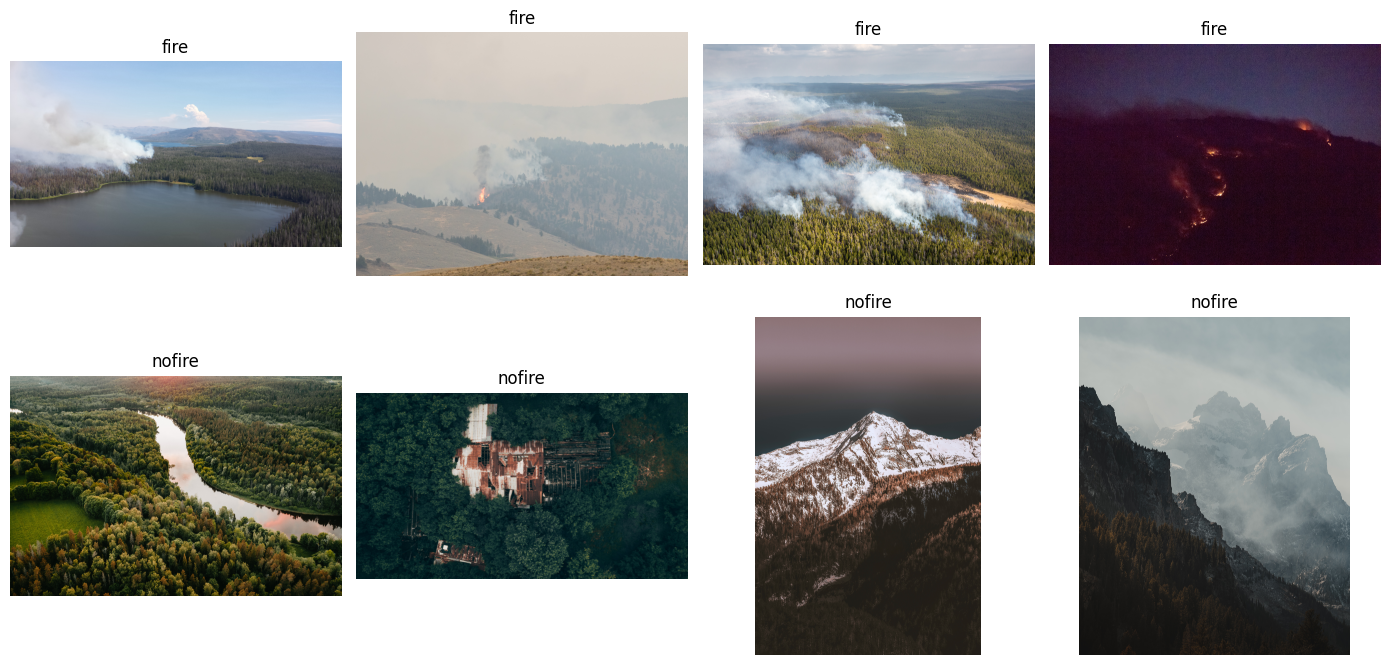

In [28]:
# Выводим по четыре случайных изображения каждого класса из train-выборки
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, 'train', class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    ]

    selected_files = random.sample(image_files, 4)

    for col, file_name in enumerate(selected_files):
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image = image.convert('RGB')

            axes[row, col].imshow(image)
            axes[row, col].set_title(class_name)
            axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Проверим, не встречаются ли дубликаты одновременно в `train`, `val` и `test`. Наличие таких файлов привело бы к утечке данных и завышенной оценке качества модели:

In [29]:
import hashlib

# Вычисляем MD5-хеш файла, чтобы сравнивать изображения по содержимому
def get_file_hash(file_path):
    file_hash = hashlib.md5()

    # Читаем файл частями, чтобы не загружать большое изображение целиком в память
    with open(file_path, 'rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            file_hash.update(chunk)

    return file_hash.hexdigest()


# Собираем уникальные хеши изображений для каждой выборки
split_hashes = {}

for split in splits:
    split_hashes[split] = set()

    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            image_path = os.path.join(class_path, file_name)
            split_hashes[split].add(get_file_hash(image_path))

# Проверяем пересечения между выборками
print('Совпадения train и val:', len(split_hashes['train'] & split_hashes['val']))
print('Совпадения train и test:', len(split_hashes['train'] & split_hashes['test']))
print('Совпадения val и test:', len(split_hashes['val'] & split_hashes['test']))

test/nofire: 100%|██████████| 251/251 [00:14<00:00, 17.92it/s]

Совпадения train и val: 0
Совпадения train и test: 0
Совпадения val и test: 0


Полных дубликатов между обучающей, валидационной и тестовой выборками не обнаружено. Явной утечки данных через одинаковые файлы нет

## Подготовка данных:

Перед обучением приведём все изображения к единому размеру `224 × 224` и цветовому режиму RGB. Уменьшенную копию сохраним отдельно, чтобы не изменять исходный датасет и ускорить загрузку изображений во время обучения.

In [27]:
from PIL import ImageOps

# Папка для подготовленной копии датасета и единый размер изображений
resized_data_dir = DATA_DIR + '_224'
target_size = (224, 224)

for split in splits:
    for class_name in classes:
        source_dir = os.path.join(DATA_DIR, split, class_name)
        target_dir = os.path.join(resized_data_dir, split, class_name)

        os.makedirs(target_dir, exist_ok=True)

        image_files = [
            file_name
            for file_name in os.listdir(source_dir)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            source_path = os.path.join(source_dir, file_name)

            # Все подготовленные изображения сохраняем в формате JPEG
            target_name = os.path.splitext(file_name)[0] + '.jpg'
            target_path = os.path.join(target_dir, target_name)

            # Не обрабатываем изображение повторно при перезапуске ячейки
            if os.path.exists(target_path):
                continue

            with Image.open(source_path) as image:
                image = ImageOps.exif_transpose(image)
                image = image.convert('RGB')

                # Приводим изображение к единому размеру без чёрных полей
                image = image.resize(target_size, Image.Resampling.LANCZOS)

                image.save(target_path, format='JPEG', quality=90)

print('Подготовленный датасет сохранён:', resized_data_dir)

test/nofire: 100%|██████████| 251/251 [00:00<00:00, 1758.50it/s]

Подготовленный датасет сохранён: /content/drive/MyDrive/СМАДИМО/ГП5/the_wildfire_dataset_2n_version_224


Проверим, что количество изображений не изменилось после обработки, а все файлы имеют размер `224 × 224` и цветовой режим RGB.

In [34]:
for split in splits:
    print(f'\n{split.upper()}')

    for class_name in classes:
        class_path = os.path.join(resized_data_dir, split, class_name)

        # После обработки все изображения сохранены в формате JPEG
        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(('.jpg', '.jpeg'))
        ]

        image_sizes = set()
        image_modes = set()

        # Проверяем характеристики всех изображений в папке
        for file_name in image_files:
            image_path = os.path.join(class_path, file_name)

            with Image.open(image_path) as image:
                image_sizes.add(image.size)
                image_modes.add(image.mode)

        # Проверяем, что количество файлов совпадает с исходным датасетом
        assert len(image_files) == class_counts[split][class_name]

        # Проверяем единый размер и цветовой режим
        assert image_sizes == {target_size}
        assert image_modes == {'RGB'}

        print(
            f'{class_name}: {len(image_files)} файлов, '
            f'размер={image_sizes}, режим={image_modes}'
        )


TRAIN
fire: 730 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 1157 файлов, размер={(224, 224)}, режим={'RGB'}

VAL
fire: 156 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 246 файлов, размер={(224, 224)}, режим={'RGB'}

TEST
fire: 159 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 251 файлов, размер={(224, 224)}, режим={'RGB'}


Подготовленный датасет содержит то же количество изображений, что и исходный. Все файлы приведены к размеру `224 × 224` и цветовому режиму RGB.

Рассчитаем среднее значение и стандартное отклонение для каждого RGB-канала по обучающей выборке. Эти значения будут использоваться для нормализации изображений перед подачей в нейросеть.

Статистики рассчитываются только по `train`, чтобы не использовать информацию из валидационной и тестовой выборок.

In [37]:
# Загружаем train-выборку без нормализации, только преобразуя изображения в тензоры
stats_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'train'),
    transform=transforms.ToTensor()
)

# Обрабатываем изображения батчами для расчёта статистик
stats_loader = DataLoader(
    stats_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in tqdm(stats_loader):
    batch_size, _, height, width = images.shape

    # Суммируем значения пикселей отдельно по каналам RGB
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    num_pixels += batch_size * height * width

# Рассчитываем среднее и стандартное отклонение по каждому каналу
train_mean = channel_sum / num_pixels
train_std = torch.sqrt(
    channel_squared_sum / num_pixels - train_mean ** 2
)

print('Mean:', train_mean.tolist())
print('Std:', train_std.tolist())

100%|██████████| 59/59 [00:09<00:00,  6.28it/s]

Mean: [0.27839380502700806, 0.27064815163612366, 0.25221458077430725]
Std: [0.2984062135219574, 0.2847074568271637, 0.2905818223953247]


По обучающей выборке рассчитаны средние значения и стандартные отклонения для каналов RGB:

Mean: [0.2784, 0.2706, 0.2522]
Std: [0.2984, 0.2847, 0.2906]

Эти значения далее используются для нормализации изображений во всех выборках. Расчёт выполнен только по train, поэтому информация из validation и test не использовалась при подготовке данных.

Преобразуем изображения в тензоры и нормализуем их с использованием статистик обучающей выборки. Затем загрузим train, validation и test из структуры папок с помощью ImageFolder.

На этом этапе аугментации не применяются, чтобы baseline-модель обучалась на исходных изображениях без дополнительных изменений.

In [38]:
# Преобразуем изображения в тензоры и нормализуем
# по статистикам, рассчитанным на train-выборке
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=train_mean.tolist(),
        std=train_std.tolist()
    )
])

# Загружаем изображения и автоматически назначаем метки
# по названиям папок fire и nofire
train_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'train'),
    transform=data_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'val'),
    transform=data_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'test'),
    transform=data_transform
)

print('Классы:', train_dataset.classes)
print('Индексы классов:', train_dataset.class_to_idx)
print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))

Классы: ['fire', 'nofire']
Индексы классов: {'fire': 0, 'nofire': 1}
Train: 1887
Validation: 402
Test: 410


Все три выборки успешно загружены. Классу fire присвоена метка 0, классу nofire — метка 1. К каждому изображению применяется преобразование в тензор и нормализация по статистикам обучающей выборки.

Создадим загрузчики данных, которые будут передавать изображения модели батчами. Обучающая выборка перемешивается перед каждой эпохой, а валидационная и тестовая сохраняют фиксированный порядок.

In [39]:
# Размер батча: количество изображений, обрабатываемых за один шаг
batch_size = 32

# Для train включаем перемешивание изображений перед каждой эпохой
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# Для validation и test перемешивание не требуется
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print('Количество батчей:')
print('Train:', len(train_loader))
print('Validation:', len(val_loader))
print('Test:', len(test_loader))

Количество батчей:
Train: 59
Validation: 13
Test: 13


Проверим размер одного батча и формат меток перед переходом к построению нейронной сети.

In [40]:
# Получаем один батч из обучающей выборки
images, labels = next(iter(train_loader))

print('Размер батча изображений:', images.shape)
print('Размер батча меток:', labels.shape)
print('Тип данных изображений:', images.dtype)
print('Метки первых изображений:', labels[:10])

Размер батча изображений: torch.Size([32, 3, 224, 224])
Размер батча меток: torch.Size([32])
Тип данных изображений: torch.float32
Метки первых изображений: tensor([0, 1, 1, 1, 1, 0, 1, 0, 1, 0])


Данные подготовлены корректно: изображения поступают батчами по 32 объекта в формате [batch_size, channels, height, width], а каждому изображению соответствует бинарная метка класса. Блок подготовки данных завершён.

# Обучение моделей

## Baseline CNN

В качестве базовой модели построим простую свёрточную нейронную сеть, обучаемую с нуля. Её результаты будут использоваться как отправная точка для сравнения с более сложными архитектурами.


In [26]:
# Зафиксируем seed для воспроизводимости

def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

Соберём основные параметры baseline-эксперимента в одном классе. Это позволит использовать одинаковые настройки при обучении и передавать их в систему логирования:

In [25]:
class CFG:

    # Параметры логирования эксперимента
    project = 'wildfire_image_classification'
    entity = 'dmshukakidze-hse-university'
    wandb = True

    # Параметры обучения
    num_epochs = 10
    train_batch_size = 32
    val_batch_size = 32
    test_batch_size = 32
    num_workers = 0
    lr = 3e-4
    seed = 42

    # Параметры данных
    image_size = 224
    classes = ('fire', 'nofire')

In [6]:
# Переведем наш класс с параметрами в словарь

def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

Строим первую базовую сеть:

In [28]:
class LeNet5(torch.nn.Module):
    def __init__(self,
                 activation='tanh',
                 pooling='avg',
                 conv_size=5
                ):
        super(LeNet5, self).__init__()

        self.conv_size = conv_size

       # установим на выбор функции активации
        if activation == 'tanh':
            activation_function = torch.nn.Tanh()
        elif activation == 'relu':
            activation_function  = torch.nn.ReLU()
        else:
            raise NotImplementedError

        # установим на выбор тип пулинга
        if pooling == 'avg':
            pooling_layer = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        elif pooling == 'max':
            pooling_layer  = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            raise NotImplementedError


        #первый сверточный блок
        if conv_size == 5:
            self.conv1 = torch.nn.Conv2d(
                in_channels=3, out_channels=6, kernel_size=5, padding=2)
        elif conv_size == 3:
            self.conv1_1 = torch.nn.Conv2d(
                in_channels=3, out_channels=6, kernel_size=3, padding=1)
            self.conv1_2 = torch.nn.Conv2d(
                in_channels=6, out_channels=6, kernel_size=3, padding=1)
        else:
            raise NotImplementedError

        self.act1 = activation_function
        self.pool1 = pooling_layer

        # второй сверточный блок
        if conv_size == 5:
            self.conv2 = torch.nn.Conv2d(
                in_channels=6, out_channels=16, kernel_size=5, padding=0)
        elif conv_size == 3:
            self.conv2_1 = torch.nn.Conv2d(
                in_channels=6, out_channels=16, kernel_size=3, padding=0)
            self.conv2_2 = torch.nn.Conv2d(
                in_channels=16, out_channels=16, kernel_size=3, padding=0)
        else:
            raise NotImplementedError

        self.act2 = activation_function
        self.pool2 = pooling_layer

        # не забываем про полносвязанные слои
        self.fc1 = torch.nn.Linear(54 * 54 * 16, 120)
        self.act3 = activation_function

        self.fc2 = torch.nn.Linear(120, 84)
        self.act4 = activation_function

        self.fc3 = torch.nn.Linear(84, 2)

    # прямой проход
    def forward(self, x):
        if self.conv_size == 5:
            x = self.conv1(x)
        elif self.conv_size == 3:
            x = self.conv1_2(self.conv1_1(x))
        x = self.act1(x)
        x = self.pool1(x)

        if self.conv_size == 5:
            x = self.conv2(x)
        elif self.conv_size == 3:
            x = self.conv2_2(self.conv2_1(x))

        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.act3(x)

        x = self.fc2(x)
        x = self.act4(x)

        x = self.fc3(x)

        return x

Создадим функцию, которая выполняет одну эпоху обучения: прямой проход, вычисление функции потерь, обратное распространение ошибки и обновление весов модели:

In [7]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    correct = 0

    for data, target in tqdm(train_loader, total=len(train_loader)):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

    # считаем метрики по всей выборке обучающей
    train_loss/= len(train_loader.dataset)
    train_accuracy =correct / len(train_loader.dataset)

    tqdm.write('\nTrain set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(train_loss, 100 * train_accuracy))

    return train_loss, train_accuracy

Напишем функцию оценки модели по валидационной выборке:

In [8]:
# функция инференса
def validate(model, device, val_loader, criterion):
    model.eval()

    val_loss = 0
    correct = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            val_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)
            correct +=pred.eq(target).sum().item()

            y_true.extend(target.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    # считаем метрики по всей валидационной выборке
    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / len(val_loader.dataset)

    val_precision_fire = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    val_recall_fire = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    val_f1_fire = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    tqdm.write('Validation set: Loss: {:.4f}, Accuracy: {:.2f}%, Precision fire: {:.4f}, Recall fire: {:.4f}, F1 fire: {:.4f}'.format(
        val_loss, 100 * val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire))

    return val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire

Объединим создание модели, выбор устройства, настройку оптимизатора и функции потерь, обучение и валидацию в единую функцию.


Вообще, наиболее важная метрика для нас - Recall, так как цена ошибки наиболее велика, если реально пожар есть, а мы его не задетектировали. Но если мы будем ориентироваться только на неё, то мы можем просто тупо на все значения говорить, что пожар есть и детектировать его даже там, где его нет. А метрика F1 - как раз учитывает это. Она учитывает и Recall и Precision. Поэтому будем ориентироваться на неё и фиксировать веса модели по наилучшему показателю этой метрике:

In [33]:
def run_experiment(model):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    architecture = model.__class__.__name__
    run_name = getattr(model, 'run_name', architecture.lower())
    model_config = getattr(model, 'model_config', {})

    experiment_config = class2dict(CFG)
    experiment_config['architecture'] = architecture
    experiment_config['selection_metric'] = 'val_f1_fire'
    experiment_config.update(model_config)

    if CFG.wandb:
        wandb.init(project=CFG.project, entity=CFG.entity or None, name=run_name, reinit=True, config=experiment_config)
        wandb.watch(model, log='all')

    optimizer = optim.Adam(model.parameters(), lr=CFG.lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision_fire': [],
        'val_recall_fire': [],
        'val_f1_fire': []
    }

    best_val_loss = 0
    best_val_accuracy = 0
    best_val_precision_fire = 0
    best_val_recall_fire = 0
    best_val_f1_fire = -1
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, CFG.num_epochs + 1):
        print(f'\nEpoch: {epoch}')

        train_loss, train_accuracy = train(model, device, train_loader, optimizer, criterion)

        val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire = validate(model, device, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_precision_fire'].append(val_precision_fire)
        history['val_recall_fire'].append(val_recall_fire)
        history['val_f1_fire'].append(val_f1_fire)

        if CFG.wandb:
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_accuracy': train_accuracy,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'val_precision_fire': val_precision_fire,
                'val_recall_fire': val_recall_fire,
                'val_f1_fire': val_f1_fire})

        # сохраняем веса с максимальным F1 по классу fire:
        if val_f1_fire > best_val_f1_fire:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_val_precision_fire = val_precision_fire
            best_val_recall_fire = val_recall_fire
            best_val_f1_fire = val_f1_fire
            best_epoch = epoch

            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

    model.load_state_dict(best_model_state)
    model = model.to(device)

    model_path = f'/content/{run_name}_best.pth'

    torch.save({
        'model_state_dict': best_model_state,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_accuracy': best_val_accuracy,
        'best_val_precision_fire': best_val_precision_fire,
        'best_val_recall_fire': best_val_recall_fire,
        'best_val_f1_fire': best_val_f1_fire,
        'config': experiment_config
    }, model_path)

    if CFG.wandb:
        wandb.run.summary['best_epoch'] = best_epoch
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_val_accuracy'] = best_val_accuracy
        wandb.run.summary['best_val_precision_fire'] = best_val_precision_fire
        wandb.run.summary['best_val_recall_fire'] = best_val_recall_fire
        wandb.run.summary['best_val_f1_fire'] = best_val_f1_fire

        #сохраняем обученную модель:
        model_artifact = wandb.Artifact(name=f'{run_name}_model', type='model')
        model_artifact.add_file(model_path)
        wandb.log_artifact(model_artifact)

        wandb.finish()


    print(
        '\nTraining is ended!',
        '\nBest epoch by F1 fire:', best_epoch,
        '\nValidation loss:', round(best_val_loss, 4),
        '\nAccuracy:', round(best_val_accuracy * 100, 2), '%',
        '\nPrecision fire:', round(best_val_precision_fire, 4),
        '\nRecall fire:', round(best_val_recall_fire, 4),
        '\nF1 fire:', round(best_val_f1_fire, 4)
      )

    return model, history

функцию активации будем использовать tanh, средний пулинг и свёрточные ядра размером 5 на 5, как в классическом варианте архитектуры

In [34]:
seed_everything(CFG.seed)

baseline_model = LeNet5(activation= 'tanh', pooling='avg', conv_size = 5)

In [36]:
summary(model=baseline_model,
        input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),  # входной батч
        col_names=['input_size', 'output_size', 'num_params', 'trainable'], # что хотим посмотреть
        col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
LeNet5                                   [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 6, 224, 224]    456                  True
├─Tanh: 1-2                              [32, 6, 224, 224]    [32, 6, 224, 224]    --                   --
├─AvgPool2d: 1-3                         [32, 6, 224, 224]    [32, 6, 112, 112]    --                   --
├─Conv2d: 1-4                            [32, 6, 112, 112]    [32, 16, 108, 108]   2,416                True
├─Tanh: 1-5                              [32, 16, 108, 108]   [32, 16, 108, 108]   --                   --
├─AvgPool2d: 1-6                         [32, 16, 108, 108]   [32, 16, 54, 54]     --                   --
├─Linear: 1-7                            [32, 46656]          [32, 120]            5,598,840            True
├─Tanh: 1-8           

Подключимся к wandb для сохранения параметров эксперимента, метрик обучения и результатов модели:

In [17]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dmshukakidze (dmshukakidze-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [37]:
baseline_model, baseline_history = run_experiment(baseline_model)


Epoch: 1


100%|██████████| 59/59 [00:10<00:00,  5.82it/s]



Train set: Average loss: 0.6552, Accuracy: 66.35%
Validation set: Loss: 0.5693, Accuracy: 72.64%, Precision fire: 0.7738, Recall fire: 0.4167, F1 fire: 0.5417

Epoch: 2


100%|██████████| 59/59 [00:09<00:00,  6.06it/s]



Train set: Average loss: 0.5456, Accuracy: 72.23%
Validation set: Loss: 0.5058, Accuracy: 73.38%, Precision fire: 0.6763, Recall fire: 0.6026, F1 fire: 0.6373

Epoch: 3


...


Train set: Average loss: 0.1467, Accuracy: 95.76%
Validation set: Loss: 0.5376, Accuracy: 76.37%, Precision fire: 0.6826, Recall fire: 0.7308, F1 fire: 0.7059

Epoch: 10


100%|██████████| 59/59 [00:10<00:00,  5.86it/s]



Train set: Average loss: 0.1043, Accuracy: 96.93%
Validation set: Loss: 0.5738, Accuracy: 75.62%, Precision fire: 0.6686, Recall fire: 0.7372, F1 fire: 0.7012


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▂▃▄▅▅▆▇██
train_loss,█▇▆▅▅▄▃▂▂▁
val_accuracy,▁▂▂▃█▇▆▄▅▄
val_f1_fire,▁▅▄▆██▇▆▇▇
val_loss,█▄▃▃▁▂▂▄▆█
val_precision_fire,█▂▅▂▇▇▃▃▂▁
val_recall_fire,▁▅▃▆▇▇█▆██
best_epoch,5
best_val_accuracy,0.79602
best_val_f1_fire,0.72667



Training is ended! 
Best epoch by F1 fire: 5 
Validation loss: 0.4463 
Accuracy: 79.6 % 
Precision fire: 0.7569 
Recall fire: 0.6987 
F1 fire: 0.7267


Посмотрим на метрики, которые мы получили:

In [39]:
baseline_logs = pd.DataFrame(baseline_history)
baseline_logs.insert(0, 'epoch', range(1, len(baseline_logs) + 1))
baseline_logs

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision_fire,val_recall_fire,val_f1_fire
0,1,0.655188,0.663487,0.569289,0.726368,0.773810,0.416667,0.541667
1,2,0.545597,0.722311,0.505818,0.733831,0.676259,0.602564,0.637288
2,3,0.491525,0.759936,0.482124,0.738806,0.725664,0.525641,0.609665
3,4,0.448285,0.788553,0.482265,0.751244,0.684211,0.666667,0.675325
4,5,0.408488,0.819290,0.446280,0.796020,0.756944,0.698718,0.726667
5,6,0.330514,0.855856,0.457500,0.791045,0.760870,0.673077,0.714286
6,7,0.270556,0.898251,0.469046,0.773632,0.701863,0.724359,0.712934
7,8,0.203252,0.926868,0.509119,0.758706,0.700680,0.660256,0.679868
8,9,0.146660,0.957605,0.537630,0.763682,0.682635,0.730769,0.705882
9,10,0.104301,0.969263,0.573826,0.756219,0.668605,0.737179,0.701220


Выведем лучшую эпоху:

In [40]:
best_baseline = baseline_logs.loc[baseline_logs['val_f1_fire'].idxmax()]
best_baseline

,4
epoch,5.000000
train_loss,0.408488
train_accuracy,0.819290
val_loss,0.446280
val_accuracy,0.796020
val_precision_fire,0.756944
val_recall_fire,0.698718
val_f1_fire,0.726667


### Вывод по baseline моделе

Лучший результат по F1 score модель показала на 5 эпохе:

Accuracy - 79,60%

Precision для класса fire — 0,7569

Recall для класса fire — 0,6987

F1-score для класса fire — 0,7267

После 5-й эпохи качество на обучающей выборке продолжает расти, но качество на валидационной выборке не улучшается. Это говорит о начале переобучения.

Baseline модель показала приемлемый результат, но надо улучшать дальше, поэтому переходим к моделе 2

## Вторая модель, более глубокая CNN

### V1

Попробуем увеличить количество свёрточных блоков и каналов, заменим tanh на relu, а средний пулинг — на максимальный. Для стабилизации обучения добавим батч нормализацию, а для снижения переобучения дропаут.

Вообще, было бы хорошо применить аугментацию, чтобы увеличить наш датасает, но пока её не применяем, чтобы отдельно оценить влияние изменения архитектуры

In [44]:
class improvedcnn(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn'

        self.model_config = {
            'channels': [32, 64, 128],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [7, 7],
            'hidden_size': 256,
            'conv_blocks': 3,
            'conv_per_block': 1
        }

        # 1 свёрточный блок
        self.conv1= nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3= nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [45]:
seed_everything(CFG.seed)

improved_model = improvedcnn()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn                              [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 32, 224, 224]   896                  True
├─BatchNorm2d: 1-2                       [32, 32, 224, 224]   [32, 32, 224, 224]   64                   True
├─MaxPool2d: 1-3                         [32, 32, 224, 224]   [32, 32, 112, 112]   --                   --
├─Conv2d: 1-4                            [32, 32, 112, 112]   [32, 64, 112, 112]   18,496               True
├─BatchNorm2d: 1-5                       [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─MaxPool2d: 1-6                         [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Conv2d: 1-7                            [32, 64, 56, 56]     [32, 128, 56, 56]    73,856               True
├─BatchNorm2d: 1-8

In [47]:
improved_model_v1, improved_history_v1 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:12<00:00,  4.61it/s]



Train set: Average loss: 0.5576, Accuracy: 73.45%
Validation set: Loss: 0.4598, Accuracy: 76.87%, Precision fire: 0.6760, Recall fire: 0.7756, F1 fire: 0.7224

Epoch: 2


100%|██████████| 59/59 [00:12<00:00,  4.55it/s]



Train set: Average loss: 0.4503, Accuracy: 78.54%
Validation set: Loss: 0.4205, Accuracy: 80.10%, Precision fire: 0.7043, Recall fire: 0.8397, F1 fire: 0.7661

Epoch: 3


...


Train set: Average loss: 0.2997, Accuracy: 86.86%
Validation set: Loss: 0.3725, Accuracy: 84.83%, Precision fire: 0.8188, Recall fire: 0.7821, F1 fire: 0.8000

Epoch: 10


100%|██████████| 59/59 [00:12<00:00,  4.54it/s]



Train set: Average loss: 0.2966, Accuracy: 86.65%
Validation set: Loss: 0.3595, Accuracy: 84.33%, Precision fire: 0.8550, Recall fire: 0.7179, F1 fire: 0.7805


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▅▆▆▇▇▇██
train_loss,█▅▄▃▃▂▂▂▁▁
val_accuracy,▁▄▃▃▅▇▆▅██
val_f1_fire,▃▆▃▁▄▇▇▇█▇
val_loss,█▅▅▆▃▃▃▄▂▁
val_precision_fire,▁▂▅█▇▇▄▃▇█
val_recall_fire,▆█▃▁▃▅██▇▅
best_epoch,9
best_val_accuracy,0.84826
best_val_f1_fire,0.8



Training is ended! 
Best epoch by F1 fire: 9 
Validation loss: 0.3725 
Accuracy: 84.83 % 
Precision fire: 0.8188 
Recall fire: 0.7821 
F1 fire: 0.8


Посмотрим на лучший результат:

In [49]:
logs_v1 = pd.DataFrame(improved_history_v1)
logs_v1.insert(0, 'epoch', range(1, len(logs_v1) + 1))

best_v1 = logs_v1.loc[logs_v1['val_f1_fire'].idxmax()]
best_v1

,8
epoch,9.000000
train_loss,0.299705
train_accuracy,0.868574
val_loss,0.372463
val_accuracy,0.848259
val_precision_fire,0.818792
val_recall_fire,0.782051
val_f1_fire,0.800000


**Вывод**
Лучший результат модель показала на 9 эпохе:

Accuracy - 84,83%

Precision для класса fire - 0,8188

Recall для класса fire - 0,7821

F1 - 0,8

Видим по всем метрикам заметное улучшение

При этом разница между Accuracy на обучающей и валидационной выборке небольшая- 86,86% и 84,83%. Сильного переобучения не наблюдается, поэтому можно проверить, даст ли увеличение мощности модели дополнительное улучшение - количество каналов увеличим с 32 64 128 до 64 128 256, а размер скрытого полносвязного слоя - с 256 до 512 нейронов:

### V2

In [50]:
class improvedcnn_v2(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn_v2, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn_v2'

        self.model_config = {
            'channels': [64, 128, 256],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [7, 7],
            'hidden_size': 512,
            'conv_blocks': 3,
            'conv_per_block': 1
        }

        # 1 свёрточный блок
        self.conv1= nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3= nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [51]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v2()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v2                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-3                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-4                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-5                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─MaxPool2d: 1-6                         [32, 128, 112, 112]  [32, 128, 56, 56]    --                   --
├─Conv2d: 1-7                            [32, 128, 56, 56]    [32, 256, 56, 56]    295,168              True
├─BatchNorm2d: 1-8

In [52]:
improved_model_v2, improved_history_v2 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:17<00:00,  3.33it/s]



Train set: Average loss: 0.7206, Accuracy: 70.48%
Validation set: Loss: 0.4617, Accuracy: 77.11%, Precision fire: 0.7051, Recall fire: 0.7051, F1 fire: 0.7051

Epoch: 2


100%|██████████| 59/59 [00:17<00:00,  3.38it/s]



Train set: Average loss: 0.4442, Accuracy: 79.70%
Validation set: Loss: 0.4416, Accuracy: 77.61%, Precision fire: 0.8367, Recall fire: 0.5256, F1 fire: 0.6457

Epoch: 3


...


Train set: Average loss: 0.3105, Accuracy: 86.22%
Validation set: Loss: 0.4458, Accuracy: 79.10%, Precision fire: 0.8750, Recall fire: 0.5385, F1 fire: 0.6667

Epoch: 10


100%|██████████| 59/59 [00:17<00:00,  3.40it/s]



Train set: Average loss: 0.2951, Accuracy: 87.49%
Validation set: Loss: 0.3910, Accuracy: 82.34%, Precision fire: 0.7742, Recall fire: 0.7692, F1 fire: 0.7717


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅▅▆▆▇▇▇▇█
train_loss,█▃▃▂▂▂▂▂▁▁
val_accuracy,▁▂▅▄▆█▇▆▄█
val_f1_fire,▄▁▆▄▅▆▆█▂▇
val_loss,█▆▄▅▃▃▁▅▇▂
val_precision_fire,▁▆▂▅▆▆▅▁█▄
val_recall_fire,▅▁▆▃▃▄▄█▁▆
best_epoch,8
best_val_accuracy,0.80846
best_val_f1_fire,0.78187



Training is ended! 
Best epoch by F1 fire: 8 
Validation loss: 0.4298 
Accuracy: 80.85 % 
Precision fire: 0.7005 
Recall fire: 0.8846 
F1 fire: 0.7819


In [53]:
logs_v2 = pd.DataFrame(improved_history_v2)
logs_v2.insert(0, 'epoch', range(1, len(logs_v2) + 1))

best_v2 = logs_v2.loc[logs_v2['val_f1_fire'].idxmax()]
best_v2

,7
epoch,8.000000
train_loss,0.337644
train_accuracy,0.855326
val_loss,0.429837
val_accuracy,0.808458
val_precision_fire,0.700508
val_recall_fire,0.884615
val_f1_fire,0.781870


**Вывод**

Количество параметров выросло примерно с 1,7 миллионов до 6,8 милионов

Лучший результат был получен на 8 эпохе:

Accuracy — 80,85%

Precision для класса fire — 0,7005

Recall для класса fire — 0,8846

F1-score для класса fire — 0,7819

Модель стала обнаруживать больше реальных пожаров, поэтому recall вырос. Однако precision и общая accuracy снизились. Модель стала чаще ошибочно относить изображения без пожара к классу fire

По сравнению с первой вариацией F1 уменьшился с 0,8 до 0,7819

Поэтому получаем, что простое увеличение количества фильтров и параметров не привело к улучшению общего качества

Далее попробуем изменить не только ширину, но и глубину модели: добавим ещё один свёрточный блок и будем использовать по две последовательные свёртки внутри каждого блока:

### V3

In [14]:
class improvedcnn_v3(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn_v3, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn_v3'

        self.model_config = {
            'channels': [64, 128, 256, 512],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [4, 4],
            'hidden_size': 512,
            'conv_blocks': 4,
            'conv_per_block': 2
        }

        # 1 свёрточный блок
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 4 свёрточный блок
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(512 * 2 * 2, 512)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool4(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [58]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v3()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v3                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─Conv2d: 1-3                            [32, 64, 224, 224]   [32, 64, 224, 224]   36,928               True
├─BatchNorm2d: 1-4                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-5                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-6                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-7                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─Conv2d: 1-8   

In [59]:
improved_model_v3, improved_history_v3 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:33<00:00,  1.75it/s]



Train set: Average loss: 0.5164, Accuracy: 74.83%
Validation set: Loss: 0.5252, Accuracy: 75.62%, Precision fire: 0.8295, Recall fire: 0.4679, F1 fire: 0.5984

Epoch: 2


100%|██████████| 59/59 [00:33<00:00,  1.76it/s]



Train set: Average loss: 0.4458, Accuracy: 79.54%
Validation set: Loss: 0.4700, Accuracy: 76.87%, Precision fire: 0.7520, Recall fire: 0.6026, F1 fire: 0.6690

Epoch: 3


...


Train set: Average loss: 0.3607, Accuracy: 84.10%
Validation set: Loss: 0.4297, Accuracy: 81.09%, Precision fire: 0.7299, Recall fire: 0.8141, F1 fire: 0.7697

Epoch: 10


100%|██████████| 59/59 [00:35<00:00,  1.65it/s]



Train set: Average loss: 0.3525, Accuracy: 83.68%
Validation set: Loss: 0.4618, Accuracy: 79.10%, Precision fire: 0.7466, Recall fire: 0.6987, F1 fire: 0.7219


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅▄▇▆▇█▇██
train_loss,█▅▄▃▃▂▂▂▁▁
val_accuracy,▁▃▃▄▆▅▅▇█▅
val_f1_fire,▁▄▄▆▇▆▆▆█▆
val_loss,█▄▃▃▃▃▄▂▁▃
val_precision_fire,█▃▃▂▁▄▂▆▂▃
val_recall_fire,▁▄▄▆▇▅▆▅█▆
best_epoch,9
best_val_accuracy,0.81095
best_val_f1_fire,0.7697



Training is ended! 
Best epoch by F1 fire: 9 
Validation loss: 0.4297 
Accuracy: 81.09 % 
Precision fire: 0.7299 
Recall fire: 0.8141 
F1 fire: 0.7697


**Вывод**

Добавление четвёртого свёрточного блока и второй свёртки внутри каждого блока не улучшило качество при прежних параметрах обучения.

Лучший F1 score составил 0,7697,

accuracy 81,09%

Accuracy на обучающей выборке составил только 84,10%, поэтому сильного переобучения не наблюдается. Скорее всего, более глубокая модель не успевает стабильно обучиться за 10 эпох с прежним значением lr.

Поэтому архитектуру оставим без изменений, но увеличим количество эпох, уменьшим lr и добавим постепенное его снижение в процессе обучения


### V4

Увеличиваем количество эпох с 10 до 25, так как более глубокая модель не успела полностью обучиться за 10 эпох

Уменьшаем lr с 3e-4 до 1e-4, чтобы обновление весов происходило более плавно и стабильно - с помощью reducelronplateau, который будет уменьшать lr в 2 раза, если F1 score поклассу fire не улучшается в течение трёх эпох

Заменяем оптимизатор adam на adamW и добавляем weight decay=1e-4, чтобы снизить переобучение

Архитектуру оставляем без изменений

Перезапишем класс и функцию:

In [32]:
class CFG:

    # Параметры логирования эксперимента
    project = 'wildfire_image_classification'
    entity = 'dmshukakidze-hse-university'
    wandb = True

    # Параметры обучения
    num_epochs = 25
    train_batch_size = 32
    val_batch_size = 32
    test_batch_size = 32
    num_workers = 0
    lr = 1e-4
    weight_decay = 1e-4
    scheduler_factor = 0.5
    scheduler_patience = 3
    min_lr = 1e-6
    seed = 42

    # Параметры данных
    image_size = 224
    classes = ('fire', 'nofire')

In [34]:
def run_experiment(model):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    architecture = model.__class__.__name__
    run_name = getattr(model, 'run_name', architecture.lower())
    model_config = getattr(model, 'model_config', {})

    experiment_config = class2dict(CFG)
    experiment_config['architecture'] = architecture
    experiment_config['selection_metric'] = 'val_f1_fire'
    experiment_config.update(model_config)

    if CFG.wandb:
        wandb.init(project=CFG.project, entity=CFG.entity or None, name=run_name, reinit=True, config=experiment_config)
        wandb.watch(model, log='all')

    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

    # Постепенно уменьшаем learning rate
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.scheduler_factor, patience=CFG.scheduler_patience, min_lr=CFG.min_lr)

    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision_fire': [],
        'val_recall_fire': [],
        'val_f1_fire': [],
        'learning_rate': []
    }

    best_val_loss = 0
    best_val_accuracy = 0
    best_val_precision_fire = 0
    best_val_recall_fire = 0
    best_val_f1_fire = -1
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, CFG.num_epochs + 1):
        print(f'\nEpoch: {epoch}')

        current_lr = optimizer.param_groups[0]['lr']

        train_loss, train_accuracy = train(model, device, train_loader, optimizer, criterion)

        val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire = validate(model, device, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_precision_fire'].append(val_precision_fire)
        history['val_recall_fire'].append(val_recall_fire)
        history['val_f1_fire'].append(val_f1_fire)
        history['learning_rate'].append(current_lr)

        if CFG.wandb:
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_accuracy': train_accuracy,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'val_precision_fire': val_precision_fire,
                'val_recall_fire': val_recall_fire,
                'val_f1_fire': val_f1_fire,
                'learning_rate': current_lr})

        # сохраняем веса с максимальным F1 по классу fire:
        if val_f1_fire > best_val_f1_fire:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_val_precision_fire = val_precision_fire
            best_val_recall_fire = val_recall_fire
            best_val_f1_fire = val_f1_fire
            best_epoch = epoch

            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

        scheduler.step(val_f1_fire)

    model.load_state_dict(best_model_state)
    model = model.to(device)

    model_path = f'/content/{run_name}_best.pth'

    torch.save({
        'model_state_dict': best_model_state,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_accuracy': best_val_accuracy,
        'best_val_precision_fire': best_val_precision_fire,
        'best_val_recall_fire': best_val_recall_fire,
        'best_val_f1_fire': best_val_f1_fire,
        'config': experiment_config
    }, model_path)

    if CFG.wandb:
        wandb.run.summary['best_epoch'] = best_epoch
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_val_accuracy'] = best_val_accuracy
        wandb.run.summary['best_val_precision_fire'] = best_val_precision_fire
        wandb.run.summary['best_val_recall_fire'] = best_val_recall_fire
        wandb.run.summary['best_val_f1_fire'] = best_val_f1_fire

        #сохраняем обученную модель:
        model_artifact = wandb.Artifact(name=f'{run_name}_model', type='model')
        model_artifact.add_file(model_path)
        wandb.log_artifact(model_artifact)

        wandb.finish()


    print(
        '\nTraining is ended!',
        '\nBest epoch by F1 fire:', best_epoch,
        '\nValidation loss:', round(best_val_loss, 4),
        '\nAccuracy:', round(best_val_accuracy * 100, 2), '%',
        '\nPrecision fire:', round(best_val_precision_fire, 4),
        '\nRecall fire:', round(best_val_recall_fire, 4),
        '\nF1 fire:', round(best_val_f1_fire, 4)
      )

    return model, history

In [35]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v3()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v3                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─Conv2d: 1-3                            [32, 64, 224, 224]   [32, 64, 224, 224]   36,928               True
├─BatchNorm2d: 1-4                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-5                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-6                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-7                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─Conv2d: 1-8   

In [36]:
improved_model_v4, improved_history_v4 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:27<00:00,  2.16it/s]



Train set: Average loss: 0.4683, Accuracy: 77.37%
Validation set: Loss: 0.4858, Accuracy: 77.11%, Precision fire: 0.6951, Recall fire: 0.7308, F1 fire: 0.7125

Epoch: 2


100%|██████████| 59/59 [00:29<00:00,  2.03it/s]



Train set: Average loss: 0.4102, Accuracy: 81.51%
Validation set: Loss: 0.4557, Accuracy: 77.86%, Precision fire: 0.7081, Recall fire: 0.7308, F1 fire: 0.7192

Epoch: 3


...


Train set: Average loss: 0.0973, Accuracy: 96.45%
Validation set: Loss: 0.3973, Accuracy: 85.07%, Precision fire: 0.8429, Recall fire: 0.7564, F1 fire: 0.7973

Epoch: 25


100%|██████████| 59/59 [00:28<00:00,  2.07it/s]



Train set: Average loss: 0.1001, Accuracy: 95.97%
Validation set: Loss: 0.4591, Accuracy: 81.34%, Precision fire: 0.7288, Recall fire: 0.8269, F1 fire: 0.7748


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,███████████████▃▃▃▃▁▁▁▁▁▁
train_accuracy,▁▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▆▇█████
train_loss,█▇▇▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▂▁▁▁▁▁
val_accuracy,▁▂▃▄▃▆▄▆▆▆▇▅▅▅▃▅▇▆▆▆█▇█▇▄
val_f1_fire,▂▂▁▄▅▅▃▅▆▆▇▄▆▆▁▆▇▆▇▆█▇█▆▅
val_loss,█▇▅▅▅▄▄▃▂▃▂▃▄▄█▅▁▄▆▂▃▄▃▄▇
val_precision_fire,▁▂▅▃▁▅▅█▅▄▄▆▃▄▇▃▇▅▃▆▅▆▆▇▂
val_recall_fire,▄▄▁▅▇▅▃▃▅▆█▃█▆▁▇▅▅█▅▇▆▇▅▇
best_epoch,21
best_val_accuracy,0.86318



Training is ended! 
Best epoch by F1 fire: 21 
Validation loss: 0.3838 
Accuracy: 86.32 % 
Precision fire: 0.8024 
Recall fire: 0.859 
F1 fire: 0.8297


### Вывод

Замена оптимизатора adam на adamW и использование адаптивного планировщика улучшили качество третьей вариации модели.

Лучший результат был получен на 21-й эпохе:

Accuracy — 86,32%

Precision — 0,8024

Recall — 0,8590

F1 score — 0,8297

По сравнению с предыдущей версией F1 score увеличился с 0,8167 до 0,8297. Особенно важным является рост Recall - модель обнаруживает около 85,9% изображений с пожаром

На лучшей эпохе accuracy на обучающей выборке составила 95,76%, а на валидационной — 86,32%. Это указывает на  переобучение. После 21-й эпохи метрики начали ухудшаться, поэтому для итоговой модели были сохранены веса именно той эпохи, на которой достигнут максимальный F1 score